In [1]:
import numpy as np
import pandas as pd
import h5py

from SushiLife import *

In [2]:
f = h5py.File("../../../../data/stock_info.hdf5", "r")
array_stock, axis_stock = load_data(f, "stock", chunks=5)
array_value, axis_value = load_data(f, "value", chunks=5)

data_stock = DataAsset(array_stock, axis_stock, chunks=5)
data_value = DataAsset(array_value, axis_value, chunks=5)

In [3]:
updater = Updater(pd.Timestamp(2002, 6, 15), data_stock.dates)

# 거래소 생성
exchange_stock = Exchange()
exchange_stock.set_DataAsset(data_stock)

# 주식 계좌 생성
stock_account = StockAccount(exchange_stock, 출력=False)

# 거래 에이전트 생성 및 주식 계좌 등록
agent = Agent(1e8, 출력=True)
agent.set_account("stock", stock_account)

# 날짜가 변할시 업데이트 요청
updater.set_data(data_stock)
updater.set_data(data_value)

updater.set_exchange(exchange_stock)

updater.set_agent(agent)

updater.initialization()

# 백테스트

columns = ["상장시가총액(원)", "지배주주순이익(원)(직전4분기)", "지배주주지분(원)",
   "현금흐름(원)(직전4분기)", "매출액(원)(직전4분기)"]

while updater._date != updater._list_date[-1]:
    fin_stat = data_value.get_info(updater._date, num=1,
                             fields=columns)
    
    상장시가총액 = fin_stat[:, 0]
    
    # 상장종목 고려
    상장종목 = ~np.isnan(상장시가총액)
    
    종목코드 = np.array(data_value.codes)[상장종목]
    상장시가총액 = 상장시가총액[상장종목]
    values = 상장시가총액.reshape(-1, 1) / fin_stat[상장종목, 1:]
    
    # 소형주
    시가총액순위 = 상장시가총액.argsort().argsort()
    시가총액조건 = 시가총액순위 < len(시가총액순위) * 0.3 # 상장종목 & 소형주
    
    values = values[시가총액조건, :]
    종목코드 = 종목코드[시가총액조건]
    
    # 양수
    cond_positive = (values > 0).all(axis=1)
    values = values[cond_positive, :]
    종목코드 = 종목코드[cond_positive]

    rank_each = values.argsort(axis=0).argsort(axis=0)
    sum_rank = np.sum(rank_each, axis=1)
    rank = sum_rank.argsort(axis=0).argsort(axis=0)

    cond_rank = rank < 50
    매수종목 = 종목코드[cond_rank]
    updater.update()

    # 매도
    매도종목 = agent.accounts["stock"].keys()
    현재가 = data_stock.get_info(updater._date, codes=매도종목, fields=["현재가"]).reshape(-1)
    
    i = 0
    for 종목코드 in 매도종목:
        매도수량 = agent.accounts["stock"][종목코드]["보유수량"]
        agent.sell("stock", 종목코드, 현재가[i], 매도수량)
        i += 1

    # 매수
    현재가 = data_stock.get_info(updater._date, codes=매수종목, fields=["현재가"]).reshape(-1)
    i = 0
    for 종목코드 in 매수종목:
        if not np.isnan(현재가[i]):
            매수수량 = int(agent.total_balance / 50 / 현재가[i])
            agent.buy("stock", 종목코드, 현재가[i], 매수수량, 주문종류="조건부지정가")
        i += 1

    for i in range(20):
        if updater._date == updater._list_date[-1]:
            break
        updater.update()

c:\users\wkwek\appdata\local\programs\python\python36\lib\site-packages\ipykernel_launcher.py:50: RuntimeWarning:

invalid value encountered in greater





 당일수익률(%) :  0.0 
 누적수익률(%) :  0.0 
 CAGR(%) 0.0 
 MDD :  0.0 
 DD :  0.0 
 총자산(원) :  100000000.0 
 --------------------------------------------------
 장시작 :  2002-06-17 00:00:00


 당일수익률(%) :  0.0 
 누적수익률(%) :  0.0 
 CAGR(%) 0.0 
 MDD :  0.0 
 DD :  0.0 
 총자산(원) :  100000000.0 
 --------------------------------------------------
 장시작 :  2002-06-18 00:00:00


 당일수익률(%) :  -3.53522 
 누적수익률(%) :  -3.5352199999999945 
 CAGR(%) -98.74627771707088 
 MDD :  -3.5352199999999945 
 DD :  -3.5352199999999945 
 총자산(원) :  96464780.0 
 --------------------------------------------------
 장시작 :  2002-06-19 00:00:00


 당일수익률(%) :  0.2464889258027645 
 누적수익률(%) :  -3.297444999999999 
 CAGR(%) -95.30956814748257 
 MDD :  -3.5352199999999945 
 DD :  -3.297444999999999 
 총자산(원) :  96702555.0 
 --------------------------------------------------
 장시작 :  2002-06-20 00:00:00


 당일수익률(%) :  0.043003000282670914 
 누적수익률(%) :  -3.2558599999999993 
 CAGR(%) -91.07515281255402 
 MDD :  -3.5352199999999945 
 DD :



 당일수익률(%) :  0.08422546944377456 
 누적수익률(%) :  -5.168571141999989 
 CAGR(%) -19.96027231044707 
 MDD :  -13.2455 
 DD :  -5.845138653925968 
 총자산(원) :  94831428.85800001 
 --------------------------------------------------
 장시작 :  2002-09-11 00:00:00


 당일수익률(%) :  0.8954362601364146 
 누적수익률(%) :  -4.319416141999987 
 CAGR(%) -16.735012364700797 
 MDD :  -13.2455 
 DD :  -5.002041884752055 
 총자산(원) :  95680583.85800001 
 --------------------------------------------------
 장시작 :  2002-09-12 00:00:00


 당일수익률(%) :  -0.379664280204564 
 누적수익률(%) :  -4.682681141999989 
 CAGR(%) -17.85501581451966 
 MDD :  -13.2455 
 DD :  -5.3627151986393455 
 총자산(원) :  95317318.85800001 
 --------------------------------------------------
 장시작 :  2002-09-13 00:00:00


 당일수익률(%) :  -0.073428418716087 
 누적수익률(%) :  -4.752671141999986 
 CAGR(%) -17.567057486718717 
 MDD :  -13.2455 
 DD :  -5.432205860384822 
 총자산(원) :  95247328.85800001 
 --------------------------------------------------
 장시작 :  2002-09-



 당일수익률(%) :  0.1414474085916938 
 누적수익률(%) :  -9.371922678500045 
 CAGR(%) -22.91620028274326 
 MDD :  -14.610708823958014 
 DD :  -10.0185017032225 
 총자산(원) :  90628077.32149996 
 --------------------------------------------------
 장시작 :  2002-11-01 00:00:00


 당일수익률(%) :  0.30092771253716166 
 누적수익률(%) :  -9.099197678500037 
 CAGR(%) -21.882881271649268 
 MDD :  -14.610708823958014 
 DD :  -9.747722438691333 
 총자산(원) :  90900802.32149996 
 --------------------------------------------------
 장시작 :  2002-11-04 00:00:00


 당일수익률(%) :  -1.5745075548815939 
 누적수익률(%) :  -10.530437678500038 
 CAGR(%) -24.874887555936255 
 MDD :  -14.610708823958014 
 DD :  -11.168751367346847 
 총자산(원) :  89469562.32149996 
 --------------------------------------------------
 장시작 :  2002-11-05 00:00:00


 당일수익률(%) :  0.7440016277357377 
 누적수익률(%) :  -9.864782678500038 
 CAGR(%) -23.28671102591946 
 MDD :  -14.610708823958014 
 DD :  -10.507845431581925 
 총자산(원) :  90135217.32149996 
 ---------------------



 당일수익률(%) :  -3.3924256831757664 
 누적수익률(%) :  -13.693729281000044 
 CAGR(%) -24.641197174840723 
 MDD :  -14.610708823958014 
 DD :  -14.309474709990678 
 총자산(원) :  86306270.71899995 
 --------------------------------------------------
 장시작 :  2002-12-23 00:00:00


 당일수익률(%) :  -2.298975478224661 
 누적수익률(%) :  -15.677889281000045 
 CAGR(%) -27.81041665899462 
 MDD :  -16.279478873569893 
 DD :  -16.279478873569893 
 총자산(원) :  84322110.71899995 
 --------------------------------------------------
 장시작 :  2002-12-24 00:00:00


 당일수익률(%) :  0.4572347593205179 
 누적수익률(%) :  -15.292339281000045 
 CAGR(%) -26.938600663480237 
 MDD :  -16.279478873569893 
 DD :  -15.896679550295579 
 총자산(원) :  84707660.71899995 
 --------------------------------------------------
 장시작 :  2002-12-26 00:00:00


 당일수익률(%) :  -2.21536043383982 
 누적수익률(%) :  -17.16891928100005 
 CAGR(%) -29.840677804936654 
 MDD :  -17.75987123508385 
 DD :  -17.75987123508385 
 총자산(원) :  82831080.71899995 
 -------------------

...



 당일수익률(%) :  -0.6531880745611182 
 누적수익률(%) :  8846.228458615205 
 CAGR(%) 32.187059207543875 
 MDD :  -59.57699737787756 
 DD :  -13.240322677168434 
 총자산(원) :  8946228458.615206 
 --------------------------------------------------
 장시작 :  2018-07-20 00:00:00


 당일수익률(%) :  -2.6734258252669467 
 누적수익률(%) :  8607.057676615206 
 CAGR(%) 31.946147048727646 
 MDD :  -59.57699737787756 
 DD :  -15.559778296635276 
 총자산(원) :  8707057676.615206 
 --------------------------------------------------
 장시작 :  2018-07-23 00:00:00


 당일수익률(%) :  0.8839043091066137 
 누적수익률(%) :  8684.019734615205 
 CAGR(%) 32.01199863704372 
 MDD :  -59.57699737787756 
 DD :  -14.813407538380066 
 총자산(원) :  8784019734.615206 
 --------------------------------------------------
 장시작 :  2018-07-24 00:00:00


 당일수익률(%) :  -0.5842233800747267 
 누적수익률(%) :  8632.701437615206 
 CAGR(%) 31.95778698455456 
 MDD :  -59.57699737787756 
 DD :  -15.311087528229821 
 총자산(원) :  8732701437.615206 
 ------------------------------

 당일수익률(%) :  0.12140828882683755 
 누적수익률(%) :  9188.706755346506 
 CAGR(%) 32.18792270266895 
 MDD :  -59.57699737787756 
 DD :  -9.91900055221569 
 총자산(원) :  9288706755.346506 
 --------------------------------------------------
 장시작 :  2018-09-07 00:00:00


 당일수익률(%) :  2.382675552467087 
 누적수익률(%) :  9410.026500346505 
 CAGR(%) 32.360963784925275 
 MDD :  -59.57699737787756 
 DD :  -7.772662600955332 
 총자산(원) :  9510026500.346506 
 --------------------------------------------------
 장시작 :  2018-09-10 00:00:00


 당일수익률(%) :  0.8266241423947209 
 누적수익률(%) :  9488.638675346507 
 CAGR(%) 32.42177795267052 
 MDD :  -59.57699737787756 
 DD :  -7.010289164126974 
 총자산(원) :  9588638675.346506 
 --------------------------------------------------
 장시작 :  2018-09-11 00:00:00


 당일수익률(%) :  -0.3486894347783083 
 누적수익률(%) :  9455.204105346505 
 CAGR(%) 32.38705276441347 
 MDD :  -59.57699737787756 
 DD :  -7.3345344612425745 
 총자산(원) :  9555204105.346506 
 ---------------------------------------



 당일수익률(%) :  0.3099860390421394 
 누적수익률(%) :  8730.691588735908 
 CAGR(%) 31.169077781469447 
 MDD :  -59.57699737787756 
 DD :  -14.360788312043294 
 총자산(원) :  8830691588.735909 
 --------------------------------------------------
 장시작 :  2018-12-17 00:00:00


 당일수익률(%) :  -0.005187623136837194 
 누적수익률(%) :  8730.23348573591 
 CAGR(%) 31.16276310094821 
 MDD :  -59.57699737787756 
 DD :  -14.365230951603012 
 총자산(원) :  8830233485.735909 
 --------------------------------------------------
 장시작 :  2018-12-18 00:00:00


 당일수익률(%) :  -0.8926506318018488 
 누적수익률(%) :  8651.410350735909 
 CAGR(%) 31.085696134942786 
 MDD :  -59.57699737787756 
 DD :  -15.129650258555587 
 총자산(원) :  8751410350.735909 
 --------------------------------------------------
 장시작 :  2018-12-19 00:00:00


 당일수익률(%) :  -0.5478716238688106 
 누적수익률(%) :  8603.463856735909 
 CAGR(%) 31.03623782965077 
 MDD :  -59.57699737787756 
 DD :  -15.594630821867176 
 총자산(원) :  8703463856.735909 
 -----------------------------



 당일수익률(%) :  1.8624152589526373 
 누적수익률(%) :  9656.15862748741 
 CAGR(%) 31.62065256311546 
 MDD :  -59.57699737787756 
 DD :  -5.38569651482069 
 총자산(원) :  9756158627.48741 
 --------------------------------------------------
 장시작 :  2019-02-12 00:00:00


 당일수익률(%) :  1.0479169610050698 
 누적수익률(%) :  9758.395068487409 
 CAGR(%) 31.697022500548687 
 MDD :  -59.57699737787756 
 DD :  -4.394217181062694 
 총자산(원) :  9858395068.48741 
 --------------------------------------------------
 장시작 :  2019-02-13 00:00:00


 당일수익률(%) :  0.5454430120363427 
 누적수익률(%) :  9812.166995487409 
 CAGR(%) 31.734027558785073 
 MDD :  -59.57699737787756 
 DD :  -3.87274211957416 
 총자산(원) :  9912166995.48741 
 --------------------------------------------------
 장시작 :  2019-02-14 00:00:00


 당일수익률(%) :  -0.6031963649040596 
 누적수익률(%) :  9752.37716448741 
 CAGR(%) 31.68029007594646 
 MDD :  -59.57699737787756 
 DD :  -4.452578244790823 
 총자산(원) :  9852377164.48741 
 --------------------------------------------



 당일수익률(%) :  0.7805357508612608 
 누적수익률(%) :  9722.421402153108 
 CAGR(%) 31.37915090795509 
 MDD :  -59.57699737787756 
 DD :  -4.743086394242421 
 총자산(원) :  9822421402.153109 
 --------------------------------------------------
 장시작 :  2019-04-03 00:00:00


 당일수익률(%) :  0.49885186140821836 
 누적수익률(%) :  9771.420734153107 
 CAGR(%) 31.412200379241064 
 MDD :  -59.57699737787756 
 DD :  -4.267895507600087 
 총자산(원) :  9871420734.153109 
 --------------------------------------------------
 장시작 :  2019-04-04 00:00:00


 당일수익률(%) :  0.36932380841457235 
 누적수익률(%) :  9807.878241153108 
 CAGR(%) 31.43516536566253 
 MDD :  -59.57699737787756 
 DD :  -3.9143340534133273 
 총자산(원) :  9907878241.153109 
 --------------------------------------------------
 장시작 :  2019-04-05 00:00:00


 당일수익률(%) :  0.1557968176868057 
 누적수익률(%) :  9823.31440015311 
 CAGR(%) 31.429775036504527 
 MDD :  -59.57699737787756 
 DD :  -3.7646356436153634 
 총자산(원) :  9923314400.153109 
 ----------------------------------

In [4]:
agent.stat("templete-numpy")

http://localhost:8097/#


,수익률(%),누적수익률(%),총자산(원),현금자산,현물자산,CAGR(%),일평균수익률(%),MDD,DD,최대수익률(%),날짜
0,0.000000,0.000000,1.000000e+08,1.000000e+08,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,2002-06-17
1,0.000000,0.000000,1.000000e+08,1.000000e+08,1.000000e+08,0.000000,0.000000,0.000000,0.000000,0.000000,2002-06-17
2,0.000000,0.000000,1.000000e+08,6.188470e+06,1.000000e+08,0.000000,0.000000,0.000000,0.000000,0.000000,2002-06-18
3,-3.535220,-3.535220,9.646478e+07,6.188470e+06,9.646478e+07,-98.746278,-1.192572,-3.535220,-3.535220,0.000000,2002-06-19
4,0.246489,-3.297445,9.670256e+07,6.188470e+06,9.670256e+07,-95.309568,-0.834755,-3.535220,-3.297445,0.000000,2002-06-20
5,0.043003,-3.255860,9.674414e+07,6.188470e+06,9.674414e+07,-91.075153,-0.659822,-3.535220,-3.255860,0.000000,2002-06-21
6,-2.440168,-5.616580,9.438342e+07,6.188470e+06,9.438342e+07,-92.844882,-0.719955,-5.616580,-5.616580,0.000000,2002-06-24
7,-0.728772,-6.304420,9.369558e+07,6.188470e+06,9.369558e+07,-92.870607,-0.720935,-6.304420,-6.304420,0.000000,2002-06-25
8,-7.408119,-13.245500,8.675450e+07,6.188470e+06,8.675450e+07,-99.440683,-1.410832,-13.245500,-13.245500,0.000000,2002-06-26
9,2.137434,-11.391180,8.860882e+07,6.188470e+06,8.860882e+07,-98.192036,-1.093422,-13.245500,-11.391180,0.000000,2002-06-27


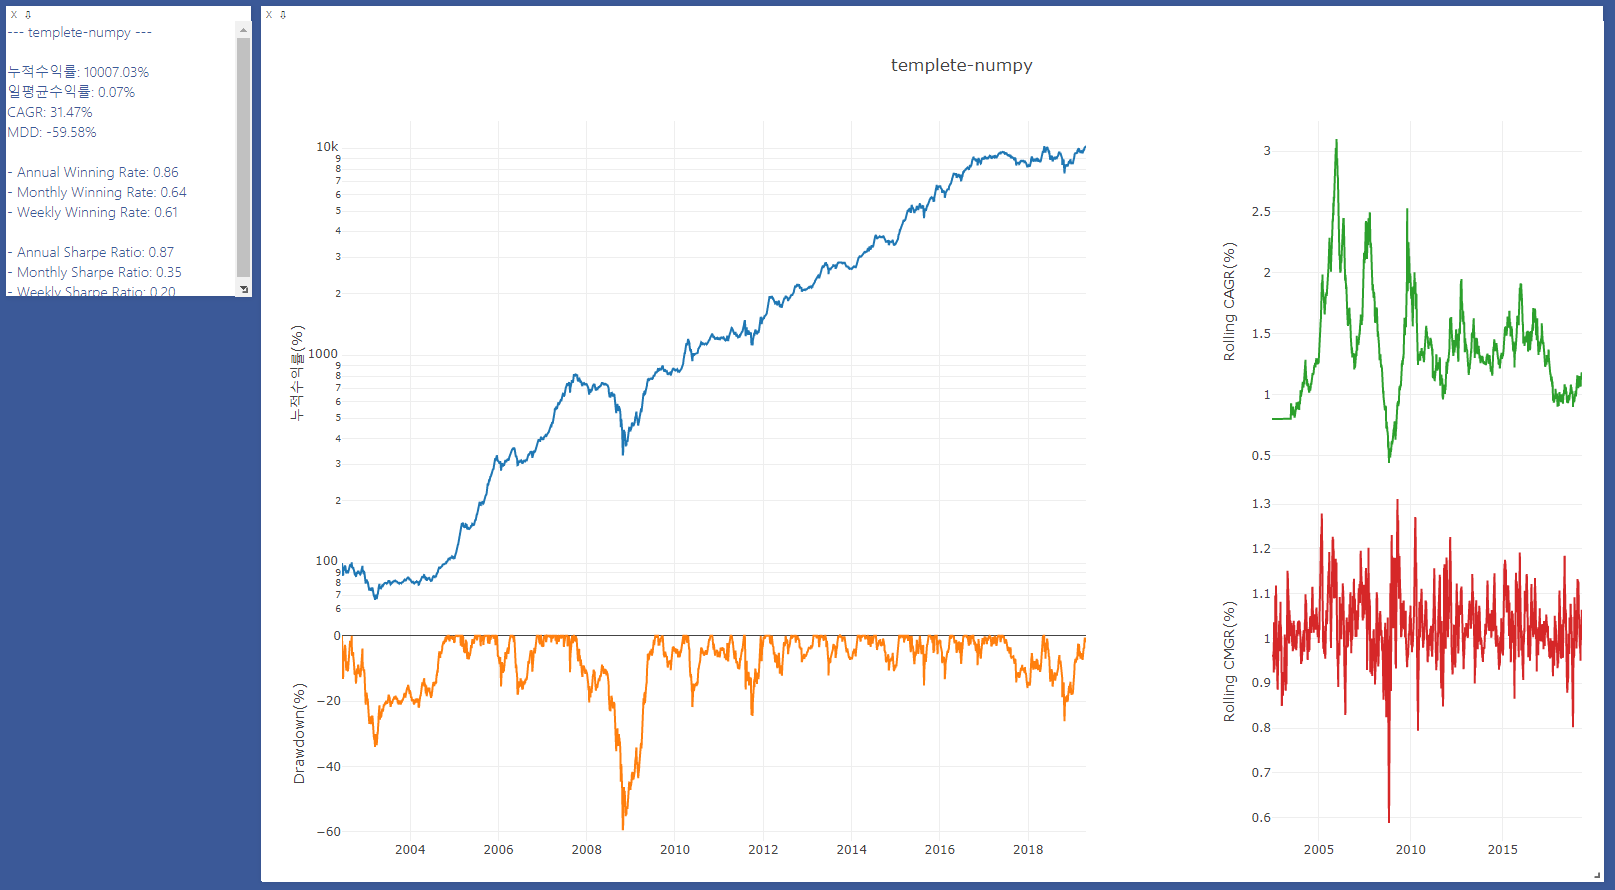